In [1]:
import numpy as np 
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy import wcs
from astrodendro import Dendrogram
from astrodendro.analysis import PPStatistic
import matplotlib.colors as colors
from spectral_cube import SpectralCube
import astropy.units as u
import matplotlib.cm as cm
import matplotlib.patheffects as path_effects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


fitsname = "../cut_restfreq.fits"
hdu = fits.open(fitsname)[0]
data = hdu.data
wcs_I = wcs.WCS(hdu.header, naxis=2)

rms=8.8e-4

# hdu_mom0 = fits.open("lb/cut-mom0.fits")[0]
# data_mom0 = hdu_mom0.data

# hdu_mom1 = fits.open("lb/cut-mom1.fits")[0]
# data_mom1 = hdu_mom1.data

cube = SpectralCube.read(fitsname)
rest_frequency = 220.071219 * u.GHz

cube = cube.with_spectral_unit(
        u.km / u.s, 
        velocity_convention='radio',  
        rest_value=rest_frequency     
    )
signal_mask = cube > (5 * rms * u.Jy/u.beam)
cube_masked = cube.with_mask(signal_mask)

mom0 = cube_masked.moment(order=0)
mom1 = cube_masked.moment(order=1)

metadata = {}
metadata["data_unit"] = cube.unit
metadata["spatial_scale"] = hdu.header["CDELT2"] * u.deg
metadata["beam_major"] = hdu.header["BMAJ"] * u.deg
metadata["beam_minor"] = hdu.header["BMIN"] * u.deg


OMP: Warning #182: GOMP_STACKSIZE: ignored because KMP_STACKSIZE has been defined
OMP: Warning #182: OMP_STACKSIZE: ignored because KMP_STACKSIZE has been defined
/Users/maixiaofeng/miniconda3/envs/astro/lib/python3.12/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


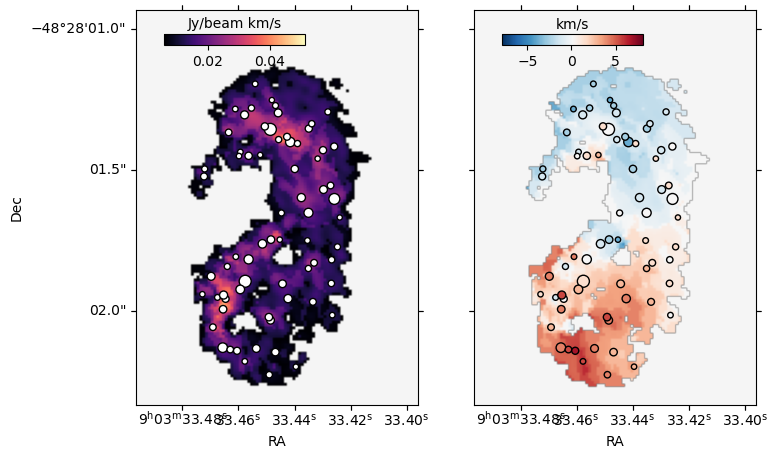

In [ ]:
min_value = 5*rms
min_delta = 1*rms
beam_size = 24


v0 = -39.767
dv = 1.331
chn_start, chn_end = 24, 36
crange = np.arange(chn_start, chn_end+1)
vrange = crange*dv + v0
v_min = np.min(vrange)
v_max = np.max(vrange)
v_norm = colors.Normalize(vmin=v_min, vmax=v_max)  

peaks = []

# mask = np.zeros(dataslice.shape, dtype=bool)
for i in range(len(crange)):
    v = vrange[i]
    dataslice = data[crange[i],:,:]
    d = Dendrogram.compute(dataslice, min_value=min_value, min_delta=min_delta, min_npix=beam_size,)
    for leaf in d.leaves:
        # mask = mask | leaf.get_mask()
        stat  = PPStatistic(leaf,metadata=metadata)
        cen   = (stat.x_cen.value, stat.y_cen.value, v, stat.flux)
        peaks.append(cen)

peak_x = np.array([p[0] for p in peaks])
peak_y = np.array([p[1] for p in peaks])
peak_v = np.array([p[2] for p in peaks]) 
peak_flux = np.array([p[3].value for p in peaks])
# s_norm = colors.Normalize(vmin=peak_flux.min(), vmax=peak_flux.max())
s_norm = colors.Normalize(vmin=np.percentile(peak_flux, 5), vmax=np.percentile(peak_flux, 95))

smin, smax = 15,60
marker_sizes = smin + (smax - smin) * s_norm(peak_flux)


fig = plt.figure(figsize=[8,6])
ax1 = fig.add_subplot(121, projection=wcs_I)
ax1.imshow(mom0.value, cmap="magma")
ax1.scatter(peak_x, peak_y, c='w', s=marker_sizes, edgecolors="k", linewidths=1)

ax2 = fig.add_subplot(122, projection=wcs_I)
ax2.imshow(mom1.value, cmap="RdBu_r", norm=v_norm)
ax2.scatter(peak_x, peak_y, c=peak_v, cmap="RdBu_r", norm=v_norm,
            edgecolors="k", linewidths=1,
            s=marker_sizes)
ax2.set_ylabel(" ")
ax2.coords[1].set_ticklabel_visible(False)

center = [190,210]
sizes = [100,140]
ax1.set_xlim([center[0]-sizes[0]/2, center[0]+sizes[0]/2])
ax1.set_ylim([center[1]-sizes[1]/2, center[1]+sizes[1]/2])
ax2.set_xlim([center[0]-sizes[0]/2, center[0]+sizes[0]/2])
ax2.set_ylim([center[1]-sizes[1]/2, center[1]+sizes[1]/2])

ax1.set_xlabel("RA")
ax1.set_ylabel("Dec")

ax2.set_xlabel("RA")

ax1.set_facecolor('whitesmoke')
ax2.set_facecolor('whitesmoke')


sm = cm.ScalarMappable(cmap="RdBu_r", norm=v_norm)
sm.set_array([])
cax = inset_axes(ax2,
                 width="50%",  
                 height="3%",   
                 loc='upper left',
                 bbox_to_anchor=(0.1, -0.06, 1, 1), 
                 bbox_transform=ax2.transAxes,
                 borderpad=0
                 ) 

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(r'km/s', color="k")
cbar.ax.tick_params(color='k', labelcolor='k')
cbar.outline.set_edgecolor('k')
cbar.ax.xaxis.set_label_position('top')



sm = cm.ScalarMappable(cmap="magma", norm=s_norm)
sm.set_array([])
cax = inset_axes(ax1,
                 width="50%",  
                 height="3%",   
                 loc='upper left',
                 bbox_to_anchor=(0.1, -0.06, 1, 1), 
                 bbox_transform=ax1.transAxes,
                 borderpad=0
                 ) 

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(r'Jy/beam km/s', color="k")
cbar.ax.tick_params(color='k', labelcolor='k')
cbar.outline.set_edgecolor('k')
cbar.ax.xaxis.set_label_position('top')

In [3]:
cx, cy = 195, 193
pixelsize = 0.01
dist = 2600 # pc


peak_x_relative = peak_x[peak_y<300] - cx
peak_y_relative = peak_y[peak_y<300] - cy
peak_x_au = peak_x_relative*pixelsize*dist
peak_y_au = peak_y_relative*pixelsize*dist
peak_v_kms = peak_v[peak_y<300]
peak_flux_1 = peak_flux[peak_y<300]


# np.savez('ppvf.npz', x=peak_x_au, y=peak_y_au, v=peak_v_kms,flux=peak_flux_1)


(-882.1375069593009,
 512.1721550047771,
 -1237.5159513216704,
 1713.9716396172566)

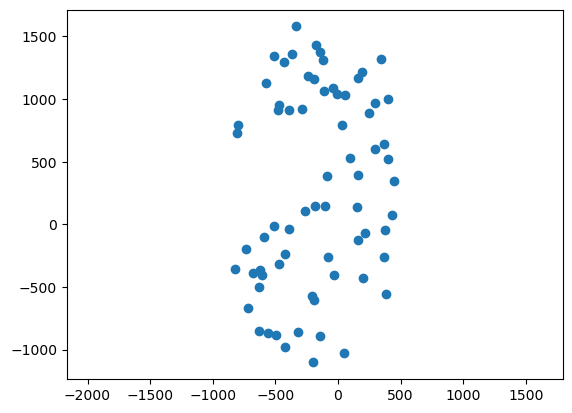

In [4]:
plt.scatter(peak_x_au,peak_y_au)
plt.axis('equal')

In [5]:
peak = np.load("../ppvf.npz")


In [6]:
from regions import Regions, PixCoord

blue_region = Regions.read("../blue-streamer-bk", format='ds9')
red_region = Regions.read("../red-streamer-bk", format='ds9')

data_blue_x = []
data_blue_y = []
data_blue_v = []
data_blue_f = []

data_red_x = []
data_red_y = []
data_red_v = []
data_red_f = []

for i in range(len(peak_x)):
    pixcoord = PixCoord(peak_x[i], peak_y[i])
    if pixcoord in blue_region[0]:
        data_blue_x.append(peak_x[i])
        data_blue_y.append(peak_y[i])
        data_blue_v.append(peak_v[i])
        data_blue_f.append(peak_flux[i])

    if pixcoord in red_region[0]:
        data_red_x.append(peak_x[i])
        data_red_y.append(peak_y[i])
        data_red_v.append(peak_v[i])
        data_red_f.append(peak_flux[i])

data_blue_x = np.array(data_blue_x)
data_blue_y = np.array(data_blue_y)
data_blue_v = np.array(data_blue_v)
data_blue_f = np.array(data_blue_f)

data_red_x = np.array(data_red_x)
data_red_y = np.array(data_red_y)
data_red_v = np.array(data_red_v)
data_red_f = np.array(data_red_f)



(161.0716343477192, 214.69892903864528, 150.38715887125653, 258.68465631865945)

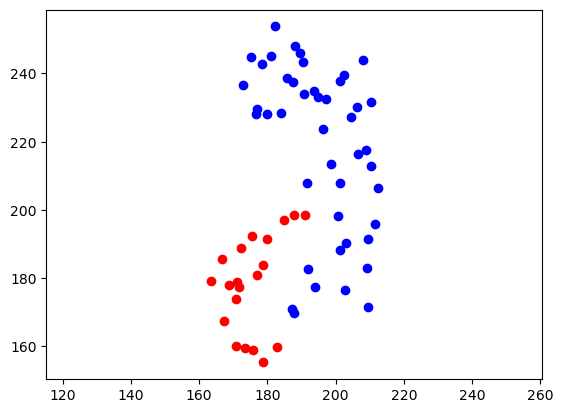

In [7]:
plt.scatter(data_blue_x, data_blue_y, c="blue")
plt.scatter(data_red_x, data_red_y, c="red")
plt.axis('equal')

In [8]:
cx, cy = 195, 193
pixelsize = 0.01
d = 2600 # pc

blue_x_relative = data_blue_x - cx
blue_y_relative = data_blue_y - cy
blue_x_relative_au = blue_x_relative*pixelsize*d
blue_y_relative_au = blue_y_relative*pixelsize*d
blue_v_kms = data_blue_v
blue_f = data_blue_f

# np.savez('blue-ppvf.npz', x=blue_x_relative_au, y=blue_y_relative_au, v=blue_v_kms,flux=blue_f)

red_x_relative = data_red_x - cx
red_y_relative = data_red_y - cy
red_x_relative_au = red_x_relative*pixelsize*d
red_y_relative_au = red_y_relative*pixelsize*d
red_v_kms = data_red_v
red_f = data_red_f

# np.savez('red-ppvf.npz', x=red_x_relative_au, y=red_y_relative_au, v=red_v_kms,flux=red_f)



(-882.1375069593009,
 512.1721550047771,
 -1107.9338693473305,
 1707.8010642851452)

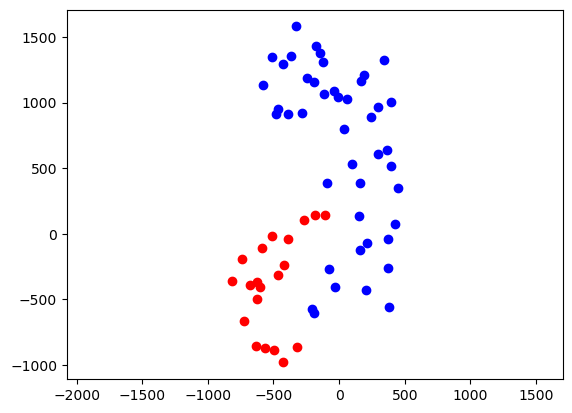

In [9]:
plt.scatter(blue_x_relative_au, blue_y_relative_au, c="blue")
plt.scatter(red_x_relative_au, red_y_relative_au , c="red")
plt.axis('equal')

In [114]:
# traj_north = np.load("ns_trajectory_no_pressure_north.npz")
# traj_south = np.load("ns_trajectory_no_pressure_south.npz")
# traj_north = np.load("orbit_view_north.npz")
traj_north = np.load("ns_trajectory_no_pressure_M_26_north.npz")

# traj_south = np.load("orbit_view.npz")
# traj_south = np.load("orbit_view_south_cluster1.npz")
traj_south = np.load("ns_trajectory_no_pressure_M_26south.npz")

trajs_ns = np.load("ns_trajectory_M_26_combined.npz")



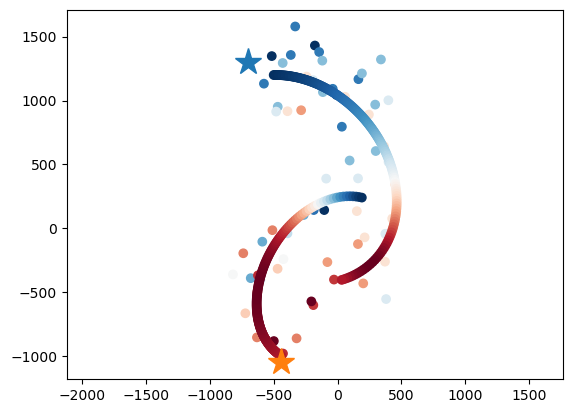

In [ ]:
traj_north_x = traj_north["x"]
traj_north_y = traj_north["y"]
traj_north_v = traj_north["v_los"]

# n_stop_south=180
traj_south_x = traj_south["x"]
traj_south_y = traj_south["y"]
traj_south_v = traj_south["v_los"]

# # combine dataset 
# traj_north_x = trajs_ns["blue_x"]
# traj_north_y = trajs_ns["blue_y"]
# traj_north_v = trajs_ns["blue_v_los"]
# traj_south_x = trajs_ns["red_x"]
# traj_south_y = trajs_ns["red_y"]
# traj_south_v = trajs_ns["red_v_los"]


plt.scatter(blue_x_relative_au, blue_y_relative_au, c=blue_v_kms, cmap="RdBu_r")
plt.scatter(red_x_relative_au, red_y_relative_au , c=red_v_kms, cmap="RdBu_r")
plt.axis('equal')

plt.scatter(traj_north_x, traj_north_y, c=traj_north_v,cmap="RdBu_r")

n_stop_south=-1
plt.scatter(traj_south_x[:n_stop_south], traj_south_y[:n_stop_south], c=traj_south_v[:n_stop_south],cmap="RdBu_r")

plt.plot(-700,1300,marker="*",markersize=20)
plt.plot(-440,-1050,marker="*",markersize=20)

In [104]:
#*pixelsize*d
dist = 2600
traj_south_x_pix = traj_south_x/pixelsize/dist+cx
traj_south_y_pix = traj_south_y/pixelsize/dist+cy
traj_north_x_pix = traj_north_x/pixelsize/dist+cx
traj_north_y_pix = traj_north_y/pixelsize/dist+cy


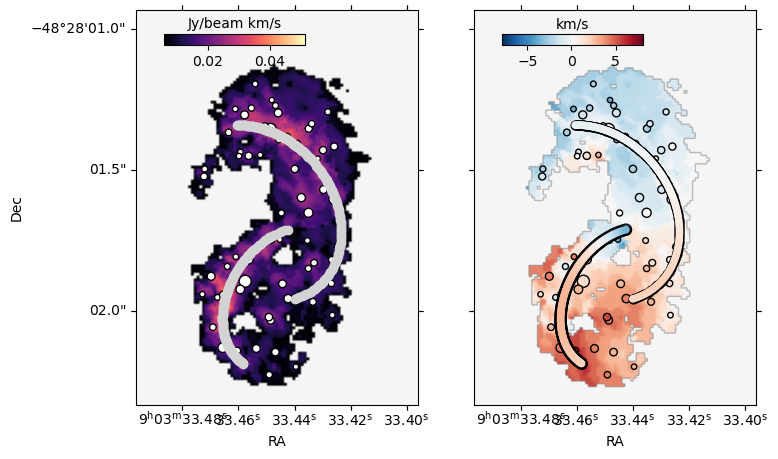

In [107]:
min_value = 5*rms
min_delta = 1*rms
beam_size = 24


v0 = -39.767
dv = 1.331
chn_start, chn_end = 24, 36
crange = np.arange(chn_start, chn_end+1)
vrange = crange*dv + v0
v_min = np.min(vrange)
v_max = np.max(vrange)
v_norm = colors.Normalize(vmin=v_min, vmax=v_max)  

peaks = []

# mask = np.zeros(dataslice.shape, dtype=bool)
for i in range(len(crange)):
    v = vrange[i]
    dataslice = data[crange[i],:,:]
    d = Dendrogram.compute(dataslice, min_value=min_value, min_delta=min_delta, min_npix=beam_size,)
    for leaf in d.leaves:
        # mask = mask | leaf.get_mask()
        stat  = PPStatistic(leaf,metadata=metadata)
        cen   = (stat.x_cen.value, stat.y_cen.value, v, stat.flux)
        peaks.append(cen)

peak_x = np.array([p[0] for p in peaks])
peak_y = np.array([p[1] for p in peaks])
peak_v = np.array([p[2] for p in peaks]) 
peak_flux = np.array([p[3].value for p in peaks])
# s_norm = colors.Normalize(vmin=peak_flux.min(), vmax=peak_flux.max())
s_norm = colors.Normalize(vmin=np.percentile(peak_flux, 5), vmax=np.percentile(peak_flux, 95))

smin, smax = 15,60
marker_sizes = smin + (smax - smin) * s_norm(peak_flux)


fig = plt.figure(figsize=[8,6])
ax1 = fig.add_subplot(121, projection=wcs_I)
ax1.imshow(mom0.value, cmap="magma")
ax1.scatter(peak_x, peak_y, c='w', s=marker_sizes, edgecolors="k", linewidths=1)

ax2 = fig.add_subplot(122, projection=wcs_I)
ax2.imshow(mom1.value, cmap="RdBu_r", norm=v_norm)
ax2.scatter(peak_x, peak_y, c=peak_v, cmap="RdBu_r", norm=v_norm,
            edgecolors="k", linewidths=1,
            s=marker_sizes)
ax2.set_ylabel(" ")
ax2.coords[1].set_ticklabel_visible(False)

center = [190,210]
sizes = [100,140]
ax1.set_xlim([center[0]-sizes[0]/2, center[0]+sizes[0]/2])
ax1.set_ylim([center[1]-sizes[1]/2, center[1]+sizes[1]/2])
ax2.set_xlim([center[0]-sizes[0]/2, center[0]+sizes[0]/2])
ax2.set_ylim([center[1]-sizes[1]/2, center[1]+sizes[1]/2])

ax1.set_xlabel("RA")
ax1.set_ylabel("Dec")

ax2.set_xlabel("RA")

ax1.set_facecolor('whitesmoke')
ax2.set_facecolor('whitesmoke')


sm = cm.ScalarMappable(cmap="RdBu_r", norm=v_norm)
sm.set_array([])
cax = inset_axes(ax2,
                 width="50%",  
                 height="3%",   
                 loc='upper left',
                 bbox_to_anchor=(0.1, -0.06, 1, 1), 
                 bbox_transform=ax2.transAxes,
                 borderpad=0
                 ) 

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(r'km/s', color="k")
cbar.ax.tick_params(color='k', labelcolor='k')
cbar.outline.set_edgecolor('k')
cbar.ax.xaxis.set_label_position('top')



sm = cm.ScalarMappable(cmap="magma", norm=s_norm)
sm.set_array([])
cax = inset_axes(ax1,
                 width="50%",  
                 height="3%",   
                 loc='upper left',
                 bbox_to_anchor=(0.1, -0.06, 1, 1), 
                 bbox_transform=ax1.transAxes,
                 borderpad=0
                 ) 

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(r'Jy/beam km/s', color="k")
cbar.ax.tick_params(color='k', labelcolor='k')
cbar.outline.set_edgecolor('k')
cbar.ax.xaxis.set_label_position('top')


# n_stop_south=220
# ax2.scatter(traj_north_x_pix, traj_north_y_pix, c=traj_north_v,cmap="RdBu_r", norm=v_norm,)
# ax2.scatter(traj_south_x_pix[:n_stop_south], traj_south_y_pix[:n_stop_south], c=traj_south_v[:n_stop_south],cmap="RdBu_r", norm=v_norm,)

###### Gemini version ######

n_stop_south = -10
# 定义基础大小和描边宽度
base_size = 20  # 根据你原本的散点大小调整
lw_stroke = 2   # 描边宽度
stroke_size = base_size + lw_stroke * 10 

# ==================== 1. 绘制北轨迹的描边底色与上色 ====================
# 先画一层稍大的黑色底（注意没有 cmap 和 c，统一用 color='black'）
ax2.scatter(traj_north_x_pix, traj_north_y_pix, s=stroke_size, color="black", zorder=3)
# 再画彩色上层
ax2.scatter(traj_north_x_pix, traj_north_y_pix, s=base_size, c=traj_north_v, 
            cmap="RdBu_r", norm=v_norm, zorder=4)

# ==================== 2. 绘制南轨迹的描边底色与上色 ====================
# 先画一层稍大的黑色底
ax2.scatter(traj_south_x_pix[:n_stop_south], traj_south_y_pix[:n_stop_south], 
            s=stroke_size, color="black", zorder=3)
# 再画彩色上层
ax2.scatter(traj_south_x_pix[:n_stop_south], traj_south_y_pix[:n_stop_south], 
            s=base_size, c=traj_south_v[:n_stop_south], cmap="RdBu_r", norm=v_norm, zorder=4)



# 绘制南轨迹并添加特效
sc_south = ax2.scatter(traj_south_x_pix[:n_stop_south], traj_south_y_pix[:n_stop_south], c=traj_south_v[:n_stop_south], cmap="RdBu_r", norm=v_norm)
sc_south.set_path_effects([
    path_effects.withStroke(linewidth=3, foreground='black')
])


ax1.scatter(traj_north_x_pix, traj_north_y_pix, color='lightgrey')
ax1.scatter(traj_south_x_pix[:n_stop_south], traj_south_y_pix[:n_stop_south], color='lightgrey')



#### plot a band
PLOT_BAND = False
if PLOT_BAND:
    from streamer_model import sample_sphere_trajectories

    trajs = sample_sphere_trajectories(                         
        x_center=-440, y_center=1200, z_center=200,    
        M=15.0,         
        v_r=-0.697, log10_omega=-4.13,                          
        theta_axis_deg=61.3, phi_axis_deg=142,    
        sphere_radius=300, n_particles=500,                                       
        # azimuth_max_delta_deg=270,
        alpha = 1e6,
    )     

    n_traj = len(trajs)
    for i in range(n_traj):
        traj_x = trajs[i][0]
        traj_y = trajs[i][1]
        # traj_z = trajs[i][2]
        traj_v = trajs[i][3]
        traj_x_pix = traj_x/pixelsize/dist+cx
        traj_y_pix = traj_y/pixelsize/dist+cy
        # ax1.plot(traj_x_pix, traj_y_pix,color="lightgrey", alpha=0.5)
        ax2.plot(traj_x_pix, traj_y_pix,color="lightgrey", alpha=0.05)


In [97]:
a = np.load("ns_trajectory_M_26_combined.npz")

In [101]:
print(a.files)

['params', 'free_names', 'blue_x', 'blue_y', 'blue_z', 'blue_v_los', 'red_x', 'red_y', 'red_z', 'red_v_los']
